# 信息熵交叉熵与KL散度

学习目标：用小型概率分布计算信息熵、交叉熵与 KL 散度，说明它们与平均负对数概率的关系，并判断零概率、计算方向和连续分布带来的边界。

前置知识：概率分布、期望、对数、数组基本运算。

运行环境：Python 3.12、NumPy、SciPy、Matplotlib；示例仅使用内存中的小型数组。

环境准备：[数学基础环境与运行说明](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

## 1 概率与自信息

### 1.1 先确定类别和概率

设一次观察只有甲、乙、丙三种结果，其概率分别为 $1/2,1/4,1/4$。用 $P$ 表示这个分布，用一维数组保存每个类别的概率；数组位置必须始终对应同一个类别。

一般地，有限类别数记为 $K$，第 $i$ 类的概率记为 $p_i$，其中 $i=1,\ldots,K$。概率满足 $p_i\geq0$ 且 $\sum_{i=1}^Kp_i=1$。比较两个分布时，仅仅数组长度相同还不够，类别及其顺序也必须一致。

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import rel_entr, xlogy
from scipy.stats import entropy

categories = np.array(["甲", "乙", "丙"])
p = np.array([0.5, 0.25, 0.25])

print("类别：", categories)  # 预期为 ['甲' '乙' '丙']。
print("概率：", p)  # 预期约为 [0.5 0.25 0.25]。
print("概率和：", p.sum())  # 1.0；三个位置依次对应甲、乙、丙。

类别： ['甲' '乙' '丙']
概率： [0.5  0.25 0.25]
概率和： 1.0


### 1.2 低概率结果带来多少信息

自信息（self-information）把某个结果在分布 $P$ 下的概率转成一个数：

$$I_P(i)=-\log_b p_i,\qquad b>1.$$

$b$ 是对数底。$p_i$ 越小，自信息越大；$p_i=1$ 时为零。这里先取 $b=2$，单位是比特（bit）：概率 $1/2$ 对应 1 bit，概率 $1/4$ 对应 2 bit。它描述结果在指定分布下有多意外，不评价消息内容是否有价值。

自然对数 $\ln$ 以 $e$ 为底，单位为纳特（nat）。因为 $\log_2 p=\ln p/\ln2$，同一个量的 bits 数值等于 nats 数值除以 $\ln2$。本章明确写出单位，不能把不同底的数值直接相减。

In [2]:
information_bits = -np.log2(p)
information_nats = -np.log(p)

print("各类别自信息 / bit：", information_bits)  # [1. 2. 2.]
print("各类别自信息 / nat：", np.round(information_nats, 6))  # 预期约为 [0.693147 1.38629 1.38629]。
print("换底一致：", np.allclose(information_bits, information_nats / np.log(2)))  # 预期为 True。

各类别自信息 / bit： [1. 2. 2.]
各类别自信息 / nat： [0.693147 1.386294 1.386294]
换底一致： True


## 2 熵是按自身概率加权的平均值

### 2.1 从三个类别手算熵

信息熵（entropy）是自信息对分布 $P$ 的期望：

$$H(P)=\mathbb E_{i\sim P}[I_P(i)]=-\sum_{i=1}^Kp_i\log_b p_i.$$

符号 $i\sim P$ 表示类别按照 $P$ 取值。上例的熵为

$$H(P)=\frac12\times1+\frac14\times2+\frac14\times2=1.5\ \text{bit}.$$

平均时使用发生概率作为权重，不能直接对三个自信息数值取算术平均。后者相当于把类别当成等概率。

In [3]:
h_bits = np.sum(p * information_bits)
h_hand = 0.5 * 1 + 0.25 * 2 + 0.25 * 2

print("加权计算 / bit：", h_bits)  # 1.5，与手算相同。
print("手算与数组一致：", np.isclose(h_bits, h_hand))  # 预期为 True。
print("直接算术平均：", information_bits.mean())  # 约 1.667，不是此分布的熵。

加权计算 / bit： 1.5
手算与数组一致： True
直接算术平均： 1.6666666666666667


### 2.2 零概率项与二元熵

当 $p_i=0$ 时，该类别不对期望贡献权重。熵中采用 $0\log0=0$ 的连续延拓约定，因为 $\lim_{t\to0^+}t\log t=0$；这不表示单独的 $\log0$ 是有限数。零概率结果的自信息按扩展值记为 $+\infty$。

直接计算零乘以对数零可能得到 NaN。SciPy 的 xlogy(x, y) 计算自然对数形式的 $x\ln y$，并在 $x=0$ 时返回零，适合保留这些约定。

对分布 $(t,1-t)$，$t\in[0,1]$，二元熵为 $-t\log_2t-(1-t)\log_2(1-t)$。下图比较确定结果与两种结果等概率时的熵；一般有限 $K$ 类分布有 $0\leq H(P)\leq\log_bK$，上界在均匀分布处达到，后面会用 KL 解释这个上界。

零概率项： 0.0
t = 0、0.5、1 时的熵 / bit： [-0.  1. -0.]


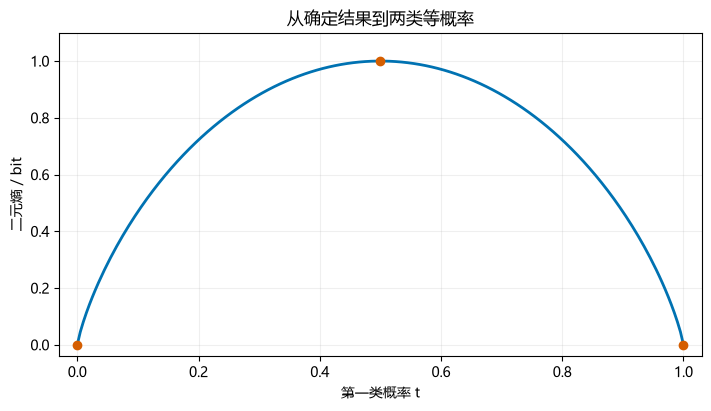

In [4]:
print("零概率项：", xlogy(0.0, 0.0))  # 0.0，不需要先计算 log(0)。

probability = np.linspace(0, 1, 201)
binary_entropy = -(
    xlogy(probability, probability) + xlogy(1 - probability, 1 - probability)
) / np.log(2)
print("t = 0、0.5、1 时的熵 / bit：", binary_entropy[[0, 100, 200]])  # 预期约为 [-0. 1. -0.]。

plt.rcParams.update({"font.family": "Microsoft YaHei", "axes.unicode_minus": False})
fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
ax.plot(probability, binary_entropy, color="#0072B2", linewidth=2)
ax.scatter([0, 0.5, 1], [0, 1, 0], color="#D55E00", zorder=3)
ax.set(xlabel="第一类概率 t", ylabel="二元熵 / bit", title="从确定结果到两类等概率")
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.04, 1.1)
ax.grid(alpha=0.2)
# 两端熵为 0，中心熵为 1 bit；曲线描述定义，没有使用随机模拟。
plt.show()

## 3 交叉熵使用谁的概率

### 3.1 发生规律与评价概率分开

交叉熵（cross-entropy）同时使用两个分布：按 $P$ 的概率加权，但用 $Q$ 分配的概率计算负对数。设 $q_i$ 为 $Q$ 对第 $i$ 类的概率，则

$$H(P,Q)=-\sum_{i=1}^Kp_i\log_b q_i.$$

仍取 $P=(1/2,1/4,1/4)$，改用 $Q=(1/4,1/2,1/4)$。此时 $Q$ 给甲分配的概率下降，而甲在 $P$ 中出现最多：

$$H(P,Q)=\frac12\times2+\frac14\times1+\frac14\times2=1.75\ \text{bit}.$$

$H(Q)$ 则是按 $Q$ 自身加权的熵，两者不是同一个对象。下面先使用严格正概率，避免对数零；零概率与支持集稍后单独处理。

In [5]:
q = np.array([0.25, 0.5, 0.25])
cross_entropy_bits = -np.sum(p * np.log2(q))

print("H(P) / bit：", h_bits)  # 1.5
print("H(P, Q) / bit：", cross_entropy_bits)  # 1.75
print("H(Q) / bit：", -np.sum(q * np.log2(q)))  # 1.5，与交叉熵不同。
print("额外的平均负对数概率 / bit：", cross_entropy_bits - h_bits)  # 0.25

H(P) / bit： 1.5
H(P, Q) / bit： 1.75
H(Q) / bit： 1.5
额外的平均负对数概率 / bit： 0.25


### 3.2 输入必须真的是概率分布

计数 $(2,1,1)$ 不是概率，除以总计数后才得到 $P$。SciPy 的 entropy 会自动归一化输入；输入两个数组时返回 KL 散度，既不是未经归一化的直接求和，也不是交叉熵。

这里直接展示计数的显式归一化。输入需为非空的一维有限非负计数，且总数为正；不同数组的类别含义与顺序应一致。非负与归一化是概率模型的前提，不通过额外检查函数代替理解。

In [6]:
# 概率需非负且总和为 1；计数必须先按总数归一化。
counts = np.array([2, 1, 1])
normalized = counts / counts.sum()
print("显式归一化：", normalized)  # [0.5  0.25 0.25]
print("概率和：", normalized.sum())  # 1.0。
print("entropy 对计数自动归一化 / bit：", entropy(counts, base=2))  # 1.5。
# [0.4, 0.4] 的和不是 1，[-0.1, 1.1] 含负数，都不能直接解释为概率分布。

显式归一化： [0.5  0.25 0.25]
概率和： 1.0
entropy 对计数自动归一化 / bit： 1.5


## 4 KL 散度比较两个分布

### 4.1 交叉熵减去熵

KL 散度（Kullback–Leibler divergence），也称相对熵，定义为

$$D_{\mathrm{KL}}(P\Vert Q)=\sum_{i:p_i>0}p_i\log_b\frac{p_i}{q_i}.$$

这里先假定所有 $p_i>0$ 的位置也有 $q_i>0$。展开对数可得

$$D_{\mathrm{KL}}(P\Vert Q)=\sum_i p_i\log_b p_i-\sum_i p_i\log_bq_i
=H(P,Q)-H(P).$$

所以 $P$ 固定时，减小交叉熵等价于减小这个方向的 KL。方向由谁提供权重决定：$D_{\mathrm{KL}}(P\Vert Q)$ 使用 $P$ 加权，而不是 $Q$。

In [7]:
kl_terms = p * np.log2(p / q)
kl_bits = kl_terms.sum()

print("各类别的 KL 项 / bit：", kl_terms)  # [0.5, -0.25, 0.0]，单项可以为负。
print("KL(P || Q) / bit：", kl_bits)  # 0.25
print("恒等式成立：", np.isclose(cross_entropy_bits, h_bits + kl_bits))  # 预期为 True。
print("SciPy 返回的 KL / bit：", entropy(p, q, base=2))  # 0.25，不是 1.75 的交叉熵。

各类别的 KL 项 / bit： [ 0.5  -0.25  0.  ]
KL(P || Q) / bit： 0.25
恒等式成立： True
SciPy 返回的 KL / bit： 0.25


### 4.2 为什么总和不会是负数

对自然对数，$\ln u\leq u-1$ 对所有 $u>0$ 成立，等号仅在 $u=1$ 时成立。令 $S_P=\{i:p_i>0\}$，即 $P$ 的支持集，把 $u=q_i/p_i$ 代入：

$$
\begin{aligned}
D_{\mathrm{KL}}(P\Vert Q)
&=-\sum_{i\in S_P}p_i\ln(q_i/p_i)\\
&\geq\sum_{i\in S_P}(p_i-q_i)
=1-\sum_{i\in S_P}q_i\geq0.
\end{aligned}
$$

等号要求 $P$ 与 $Q$ 完全相同，包括支持集外的概率。换成任意 $b>1$ 只乘以正数 $1/\ln b$，不改变非负性。如果某个 $p_i>0$ 对应 $q_i=0$，KL 为正无穷，也不违背非负性。

令 $U$ 为 $K$ 类均匀分布，则 $D_{\mathrm{KL}}(P\Vert U)=\log_bK-H(P)\geq0$，这就得到熵的上界。下限 $H(P)\geq0$ 则来自每个 $-p_i\log_b p_i\geq0$。数值核对帮助理解，证明来自上面的不等式。

In [8]:
uniform = np.full(p.size, 1 / p.size)
kl_to_uniform = entropy(p, uniform, base=2)

print("均匀分布的熵 / bit：", entropy(uniform, base=2))  # log2(3)，约 1.585。
print("KL(P || U) / bit：", kl_to_uniform)  # 约 0.085。
print("上界差值一致：", np.isclose(kl_to_uniform, np.log2(p.size) - h_bits))  # 预期为 True。
print("同分布的 KL：", entropy(p, p, base=2))  # 0.0

均匀分布的熵 / bit： 1.584962500721156
KL(P || U) / bit： 0.08496250072115627
上界差值一致： True
同分布的 KL： 0.0


### 4.3 调换方向会改变数值

KL 一般不对称，因此不能当成满足对称性的距离。考虑 $P_2=(0.8,0.2)$ 与 $Q_2=(0.5,0.5)$：正向的权重是 $(0.8,0.2)$，反向的权重是 $(0.5,0.5)$，对数比值也相反。

后续代码默认使用自然对数，单位统一为 nat；前面的 bit 结果若参与比较，必须先换底。

In [9]:
p_two = np.array([0.8, 0.2])
q_two = np.array([0.5, 0.5])

print("KL(P2 || Q2) / nat：", entropy(p_two, q_two))  # 约 0.192745。
print("KL(Q2 || P2) / nat：", entropy(q_two, p_two))  # 约 0.223144，不相等。
print("H(P2, Q2) / nat：", -xlogy(p_two, q_two).sum())  # 预期约为 0.693147。
print("H(Q2, P2) / nat：", -xlogy(q_two, p_two).sum())  # 预期约为 0.916291。
# 交叉熵也要写明两个对象，交换它们通常会改变结果。

KL(P2 || Q2) / nat： 0.19274475702175753
KL(Q2 || P2) / nat： 0.2231435513142097
H(P2, Q2) / nat： 0.6931471805599453
H(Q2, P2) / nat： 0.916290731874155


## 5 零概率与支持不匹配

### 5.1 哪种零会产生无穷大

对离散有限分布，逐项约定如下。两数组必须先满足概率条件。

| 概率条件 | 对交叉熵的贡献 $-p_i\ln q_i$ | 对 KL 的贡献 $p_i\ln(p_i/q_i)$ |
| --- | --- | --- |
| $p_i=0,\ q_i\geq0$ | 0 | 0 |
| $p_i>0,\ q_i>0$ | 有限值 | 有限值 |
| $p_i>0,\ q_i=0$ | $+\infty$ | $+\infty$ |

因此 KL 有限的充要条件是 $S_P\subseteq S_Q$，其中 $S_Q=\{i:q_i>0\}$。这个结论限定为有限类别；无限类别还需要控制无穷求和。

例如 $P_0=(1,0)$、$Q_0=(1/2,1/2)$，正向 KL 为 $\ln2$，反向却为无穷大。SciPy 的 rel_entr 按上述约定逐元素计算自然对数形式的 KL 项；xlogy 可以用于交叉熵。

In [10]:
p_zero = np.array([1.0, 0.0])
q_zero = np.array([0.5, 0.5])

print("KL(P0 || Q0) / nat：", rel_entr(p_zero, q_zero).sum())  # ln(2)。
print("KL(Q0 || P0) / nat：", rel_entr(q_zero, p_zero).sum())  # inf。
print("H(Q0, P0) / nat：", -xlogy(q_zero, p_zero).sum())  # inf。
print("共同零项：", rel_entr(0.0, 0.0), xlogy(0.0, 0.0))  # 都是 0.0。
print("H(P0) / nat：", -xlogy(p_zero, p_zero).sum())  # 零熵。

KL(P0 || Q0) / nat： 0.6931471805599453
KL(Q0 || P0) / nat： inf
H(Q0, P0) / nat： inf
共同零项： 0.0 0.0
H(P0) / nat： -0.0


### 5.2 加一个小数改变了分布

为避免无穷大而把零概率改成正数，实际是在修改 $Q$。必须说明改法并重新归一化，不能声称所得有限值仍是原分布的 KL。

下面把 $Q=(1,0)$ 的第二类改为 $\varepsilon$，同时把第一类改为 $1-\varepsilon$，其中 $0<\varepsilon<1$。对 $P=(1/2,1/2)$，交叉熵为 $-\tfrac12\ln(1-\varepsilon)-\tfrac12\ln\varepsilon$；当 $\varepsilon\to0^+$ 时趋于无穷大。数值越有限并不代表这个建模选择越合理。

In [11]:
for epsilon in (1e-1, 1e-3, 1e-6):
    q_changed = np.array([1 - epsilon, epsilon])
    ce_changed = -xlogy(q_zero, q_changed).sum()
    kl_changed = rel_entr(q_zero, q_changed).sum()
    # epsilon 减小时，CE 约从 1.204 增至 6.908 nat，KL 从 0.511 增至 6.215 nat。
    print(f"epsilon={epsilon:.0e}，交叉熵={ce_changed:.6f}，KL={kl_changed:.6f} nat")
# epsilon 越接近 0，本例两项越大；原始 Q=(1, 0) 的结果仍为正无穷。

epsilon=1e-01，交叉熵=1.203973，KL=0.510826 nat
epsilon=1e-03，交叉熵=3.454378，KL=2.761231 nat
epsilon=1e-06，交叉熵=6.907756，KL=6.214609 nat


## 6 改变预测概率观察三个量

令参考分布 $P=(0.7,0.3)$ 固定，预测分布 $Q_r=(r,1-r)$，其中 $0<r<1$。$H(P)$ 不随 $r$ 改变，而

$$H(P,Q_r)=-0.7\ln r-0.3\ln(1-r).$$

对 $r$ 求导，$H'(r)=-0.7/r+0.3/(1-r)$，等于零时有 $r=0.7$。二阶导数 $H''(r)=0.7/r^2+0.3/(1-r)^2>0$，因此该点是唯一最小值；此时 $Q_r=P$，KL 为零。

下图把交叉熵与 KL 放在同一坐标系中。两条曲线的竖直差始终是固定的 $H(P)$；图形只是这个恒等式的数值展示，有限网格不能替代最小值的推导。

整条网格满足 CE = H + KL： True
r = 0.7 时的 KL： 0.0


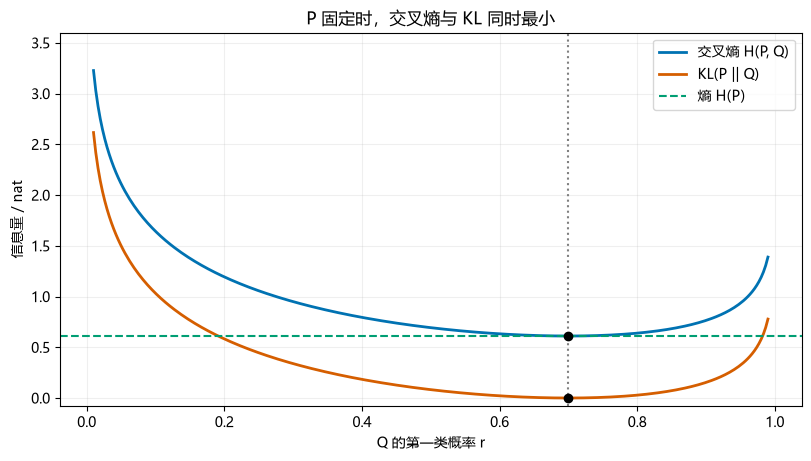

In [12]:
p_curve = np.array([0.7, 0.3])
r = np.linspace(0.01, 0.99, 301)
# 每行是一组二分类预测分布；P 广播到所有行，沿类别轴求和。
q_curve = np.column_stack([r, 1 - r])
h_curve = entropy(p_curve)
ce_curve = -xlogy(p_curve, q_curve).sum(axis=1)
kl_curve = rel_entr(p_curve, q_curve).sum(axis=1)

print("整条网格满足 CE = H + KL：", np.allclose(ce_curve, h_curve + kl_curve))  # 预期为 True。
print("r = 0.7 时的 KL：", rel_entr(p_curve, p_curve).sum())  # 0.0。

# P 保持不变，因此熵画成水平线；另外两条曲线随 Q 变化。
fig, ax = plt.subplots(figsize=(8, 4.5), layout="constrained")
ax.plot(r, ce_curve, label="交叉熵 H(P, Q)", color="#0072B2", linewidth=2)
ax.plot(r, kl_curve, label="KL(P || Q)", color="#D55E00", linewidth=2)
ax.axhline(h_curve, color="#009E73", linestyle="--", label="熵 H(P)")
ax.axvline(0.7, color="0.5", linestyle=":")
ax.scatter([0.7, 0.7], [h_curve, 0], color="black", zorder=3)
ax.set(
    xlabel="Q 的第一类概率 r",
    ylabel="信息量 / nat",
    title="P 固定时，交叉熵与 KL 同时最小",
)
ax.set_ylim(-0.08, 3.6)
ax.legend()
ax.grid(alpha=0.2)
# r=0.7 处交叉熵为 H(P)，KL 为零；横轴端点 0 和 1 未计算。
plt.show()

## 7 综合应用：平均负对数概率

### 7.1 把样本平均改写成经验交叉熵

有 $n$ 条分类观察 $y_1,\ldots,y_n$，每个 $y_j$ 都是一个类别编号。令 $n_i$ 为第 $i$ 类出现次数，经验分布为 $\widehat p_i=n_i/n$。如果对每条观察都用同一个分布 $Q$ 评分，把同类样本合并便有

$$L(Q)=-\frac1n\sum_{j=1}^n\ln q_{y_j}
=-\sum_{i=1}^K\frac{n_i}{n}\ln q_i
=H(\widehat P,Q).$$

$L$ 是平均负对数概率，也称平均负对数似然（negative log-likelihood，NLL）。如果还假定这些观察独立同分布于模型 $Q$，联合似然就是 $\prod_{j=1}^nq_{y_j}$，取负对数后除以 $n$ 得到同一个式子。样本分组恒等式本身不要求独立性。

下面用 20 条人工指定的观察比较三种固定预测分布。经验分布来自这批样本，不应直接当成未知总体的真实分布；本例比较的是这批数据上的分数。

In [13]:
labels = np.array([0] * 12 + [1] * 6 + [2] * 2)
observed_counts = np.bincount(labels, minlength=3)
empirical_p = observed_counts / labels.size
models = {
    "A": np.array([0.6, 0.3, 0.1]),
    "B": np.array([0.8, 0.15, 0.05]),
    "C": np.array([0.45, 0.35, 0.2]),
}

print("计数与经验分布：", observed_counts, empirical_p)  # 预期约为 [12 6 2] [0.6 0.3 0.1]。
print("模型     平均 NLL       交叉熵            KL（均为 nat）")
for name, model_q in models.items():
    # 每个标签挑出对应类别概率，再在 20 条观测之间取平均。
    mean_nll = -np.log(model_q[labels]).mean()
    ce = -xlogy(empirical_p, model_q).sum()
    kl = rel_entr(empirical_p, model_q).sum()
    # 每行平均 NLL 与 CE 相等；A、B、C 的 CE 约 0.897946、1.002595、0.954995 nat，A 的 KL 为 0。
    print(f"{name}       {mean_nll:.6f}       {ce:.6f}       {kl:.6f}")
    assert np.isclose(mean_nll, ce)
    assert np.isclose(ce, entropy(empirical_p) + kl)
# A 恰好等于经验分布，KL 为零；B、C 的交叉熵都更高，C 低于 B。

计数与经验分布： [12  6  2] [0.6 0.3 0.1]
模型     平均 NLL       交叉熵            KL（均为 nat）
A       0.897946       0.897946       0.000000
B       1.002595       1.002595       0.104650
C       0.954995       0.954995       0.057049


### 7.2 每条输入有自己的预测分布

分类模型通常给不同输入分配不同的概率向量。此时用 $q_{j,i}$ 表示第 $j$ 条输入对第 $i$ 类的预测概率，每一行都要归一化；不能先把各行平均，再套用上一节的固定 $Q$ 公式。

对第 $j$ 条样本，令目标向量 $t_{j,i}$ 在真实类别 $i=y_j$ 处为 1，其余位置为 0，这称为独热编码（one-hot encoding）。该行交叉熵为

$$-\sum_{i=1}^Kt_{j,i}\ln q_{j,i}=-\ln q_{j,y_j}.$$

所以逐行交叉熵再平均，才等于这个模型的平均 NLL。这里每行目标熵为零；如果目标本身是软概率分布，就仍需保留 $H(P)$ 项。以下数组中的类别编号从 0 开始，与 Python 索引一致。

In [14]:
row_labels = np.array([0, 1, 2, 0])
row_q = np.array([[0.8, 0.1, 0.1], [0.2, 0.7, 0.1], [0.2, 0.3, 0.5], [0.4, 0.5, 0.1]])

# 每行是一条观测，每列是一个类别；独热目标只保留该行真实类别的贡献。
targets = np.eye(3)[row_labels]
row_ce = -xlogy(targets, row_q).sum(axis=1)
# 同时用行号和类别号索引，每行恰好取出一个真实类别概率。
row_nll = -np.log(row_q[np.arange(row_labels.size), row_labels])
print("每行交叉熵 / nat：", np.round(row_ce, 6))  # 预期约为 [0.223144 0.356675 0.693147 0.916291]。
print("逐行 CE 与 NLL 一致：", np.allclose(row_ce, row_nll))  # 预期为 True。
print("正确的平均 NLL / nat：", row_nll.mean())  # 约 0.547314。

average_q = row_q.mean(axis=0)
print("先平均预测后的分数 / nat：", -np.log(average_q[row_labels]).mean())  # 预期约为 1.08958。
# 后一个数对应另一种固定预测分布，不是原来逐输入模型的平均 NLL。

每行交叉熵 / nat： [0.223144 0.356675 0.693147 0.916291]
逐行 CE 与 NLL 一致： True
正确的平均 NLL / nat： 0.5473141019217607
先平均预测后的分数 / nat： 1.0895775270141415


## 8 连续分布的边界

### 8.1 密度不是单点概率

前面的求和针对有限分类概率。若实值随机变量有密度 $f(x)$，则 $f(x)\geq0$ 且 $\int_{\mathbb R}f(x)\,dx=1$；密度可以大于 1，单点概率则为零。不能对每个单点概率取对数，再把离散公式搬过来。

在积分存在且有意义时，微分熵（differential entropy）定义为

$$h(f)=-\int_{\mathbb R}f(x)\ln f(x)\,dx.$$

例如在 $[0,a]$ 上均匀分布，$a>0$，密度为 $1/a$，直接积分得到 $h(f)=\ln a$。当 $a<1$ 时它为负，与离散熵非负并不冲突。把以米计的坐标换成厘米，相当于 $Y=100X$，微分熵增加 $\ln100$；因此比较时还必须统一坐标单位。一般 $Y=cX$、$c\ne0$ 时，$h(Y)=h(X)+\ln\lvert c\rvert$，前提是有关微分熵存在。

In [15]:
widths = np.array([0.25, 1.0, 4.0])
density_values = 1 / widths
differential_entropy = -widths * xlogy(density_values, density_values)

print("区间宽度：", widths)  # 预期约为 [0.25 1. 4. ]。
print("均匀密度：", density_values)  # 宽度为 0.25 时密度为 4，仍积分为 1。
print("微分熵 / nat：", np.round(differential_entropy, 6))  # 约为 [-1.386294, 0, 1.386294]。
print("积分与 ln(a) 一致：", np.allclose(differential_entropy, np.log(widths)))  # 预期为 True。

width_metres = 0.25
width_centimetres = 100 * width_metres
print("换单位后的微分熵差 / nat：", np.log(width_centimetres) - np.log(width_metres))  # 预期约为 4.60517。
print("ln(100)：", np.log(100))  # 约 4.60517；同一物理分布改变坐标单位后微分熵变化。

区间宽度： [0.25 1.   4.  ]
均匀密度： [4.   1.   0.25]
微分熵 / nat： [-1.386294 -0.        1.386294]
积分与 ln(a) 一致： True
换单位后的微分熵差 / nat： 4.605170185988091
ln(100)： 4.605170185988092


### 8.2 连续 KL 仍比较同一坐标下的两个分布

若 $P,Q$ 分别有密度 $f,g$，并使用同一个坐标与积分测度，连续 KL 为

$$D_{\mathrm{KL}}(P\Vert Q)=\int_{\mathbb R}f(x)\ln\frac{f(x)}{g(x)}\,dx.$$

这里零密度项按与离散情形一致的方式处理。如果存在 $P$ 赋予正概率、但 $Q$ 赋予零概率的区域，正向 KL 为无穷大；孤立点的密度取值不会改变积分。即使不存在这种区域，积分尾部也仍可能让 KL 发散，所以连续情形不能只用支持集判断有限性。

若交叉熵 $-\int f\ln g$ 和微分熵都有限，仍可拆成“交叉熵减微分熵”；存在无穷量时不能直接做 $\infty-\infty$。连续 KL 非负，等于零意味着两个密度几乎处处相同，即除去积分测度为零的集合后相同。

用 $P$ 在 $[0,1]$ 上均匀、$Q$ 在 $[0,2]$ 上均匀的小例子核对：正向 KL 为 $\int_0^1\ln2\,dx=\ln2$，反向因为区间 $(1,2]$ 而为无穷大。两个坐标同时放大 100 倍时，密度都除以 100，密度比不变，积分中的密度与区间长度也抵消，因此本例 KL 不变。

In [16]:
for scale in (1.0, 100.0):
    p_width = scale
    q_width = 2 * scale
    f = 1 / p_width
    g = 1 / q_width
    continuous_kl = p_width * f * np.log(f / g)
    print(f"坐标缩放 {scale:g} 倍：正向 KL = {continuous_kl:.6f} nat")  # 两种单位下的正向 KL 都约为 0.693147 nat。
# 两次都为 ln(2)，约 0.693147；反向有 Q 正概率而 P 为零的整个区域，故为无穷大。

坐标缩放 1 倍：正向 KL = 0.693147 nat
坐标缩放 100 倍：正向 KL = 0.693147 nat


## 本章小结

（1）自信息评价一个结果，熵是按自身概率加权的平均自信息。对数底决定单位：自然对数使用 nat，底为 2 使用 bit。

（2）交叉熵 $H(P,Q)$ 用 $P$ 加权、用 $Q$ 计算负对数。有限分类分布中，$H(P,Q)=H(P)+D_{\mathrm{KL}}(P\Vert Q)$；$P$ 固定时两种比较具有相同的最优点。

（3）KL 非负且一般不对称。先核对类别顺序、归一化与支持集；给零概率补数会改变分布，不能悄悄把无穷大改成有限结果。

（4）固定分布的平均 NLL 等于对经验分布的交叉熵；每条输入的预测不同时，应逐行计算再平均。连续密度则使用积分，微分熵可以为负且依赖坐标单位。

自查：如果 $P$ 在某类上的概率为零，而 $Q$ 非零，为什么正向 KL 的该项仍为零？反向会怎样？

## 练习

（1）计数、类别顺序与信息单位。

三个类别甲、乙、丙的计数为 $(6,3,1)$，预测概率依次为 $(0.5,0.3,0.2)$。把计数归一化，计算熵、交叉熵和 KL，分别报告 bit 与 nat，并检查换底关系。再把预测数组的甲、丙位置交换，保持经验分布不变，解释为什么概率和仍为 1 却不是同一个比较。

核对标准：原始交叉熵不小于经验熵；两个单位下均满足 $H(P,Q)=H(P)+D_{\mathrm{KL}}(P\Vert Q)$。这里交换的是预测类别含义，不是把两个数组一起重命名。

In [17]:
exercise_counts = np.array([6, 3, 1])
exercise_q = np.array([0.5, 0.3, 0.2])

# 在这里归一化计数，计算三个量，并交换预测数组的第 0、2 项后重新比较。

（2）先判断支持集，再计算。

给定 $P=(0.5,0.5,0)$、$Q=(0.5,0,0.5)$，先预测两个方向的 KL 是否有限，再用 rel_entr 检查。之后令 $Q_\varepsilon=(0.5,\varepsilon,0.5-\varepsilon)$，分别取 $\varepsilon=0.1,0.01,0.001$，比较正向 KL。

核对标准：说明原来哪个类别产生无穷大；修改后的概率非负且和为 1。解释 $\varepsilon$ 接近零时的趋势，以及为什么不能把修改后结果当成原 $Q$ 的有限近似值而不说明改动。

In [18]:
exercise_p_zero = np.array([0.5, 0.5, 0.0])
exercise_q_zero = np.array([0.5, 0.0, 0.5])

# 先写下两个方向的预测，再计算；保持每个修改后的分布归一化。

（3）逐条预测与先平均预测。

两条观察的真实类别分别为 0、1，两行预测分别为 $(0.9,0.1)$、$(0.1,0.9)$。分别计算逐行平均 NLL，以及先把两行预测平均后得到的分数。再交换这两行预测，保持标签不变，比较两个分数如何变化。

核对标准：交换前后平均预测完全相同，但逐行 NLL 不同；用独热目标的交叉熵核对逐行结果，并解释丢失了什么对应关系。

In [19]:
exercise_labels = np.array([0, 1])
exercise_rows = np.array([[0.9, 0.1], [0.1, 0.9]])

# 分别使用原矩阵和交换行后的矩阵，核对预测与标签的对应关系。

（4）连续分布的单位与方向。

令 $P$ 在 $[0,0.5]$ 上均匀，$Q$ 在 $[0,1]$ 上均匀。手算 $P$ 的微分熵以及两个方向的 KL；再把两个变量的坐标都乘以 10，重新计算。

核对标准：微分熵增加 $\ln10$，有限方向的 KL 保持不变，反向依旧存在支持不匹配。说明为什么负的微分熵不违反离散熵非负，以及为什么这里不能把密度数组直接交给 entropy 来代替积分。

In [20]:
exercise_p_width = 0.5
exercise_q_width = 1.0
exercise_scale = 10.0

# 从均匀密度和积分区间手算，再用数值核对单位变化；不要把密度当成类别概率。

## 练习提示与解析

以下对应练习（3）。先独立作答，卡住时依次查看提示，完成后再对照解析。

提示 1：逐行 NLL 使用每一行真实标签对应的概率。

提示 2：平均预测会抹掉行与标签的对应；检查交换行前后哪个量仍然相同。

### 练习（3）参考解析

原预测对两条真实标签都给出 0.9，所以平均 NLL 为 $-\ln0.9\approx0.10536$ nat。先平均预测得到 $(0.5,0.5)$，再对两条标签评分则为 $-\ln0.5\approx0.69315$ nat。

交换两行但保持标签不变后，逐行真实标签概率都变成 0.1，平均 NLL 为 $-\ln0.1\approx2.30259$ nat；平均预测及其分数却完全不变。用独热标签计算交叉熵时，每行只剩真实类别的对数项，正好恢复逐行 NLL。评估配对预测必须保留这种逐条对应关系。

## 参考与引用来源

| 网站 | 本章参考内容与定位 |
| --- | --- |
| Deep Learning 作者网站 | Goodfellow、Bengio、Courville：[Chapter 3, Probability and Information Theory](https://www.deeplearningbook.org/contents/prob.html)，§3.3.1–3.3.2（书页 54–56）：概率质量函数与密度的归一化条件；§3.13（书页 71–74），式 (3.48)–(3.51)：自信息、信息单位、熵、KL、交叉熵与零概率约定。本文采用原创类别数据与计算示例。 |
| Stanford EE376A 课程网站 | Tsachy Weissman 课程讲义：[Lecture 3: Entropy, Relative Entropy, and Mutual Information](https://web.stanford.edu/class/ee376a/files/lecture_3.pdf)，第 1–3 页、§2–2.1：熵、均匀分布上界、交叉熵不小于熵及相对熵非负；[Lecture 8: Channel Capacity, Continuous Random Variables](https://web.stanford.edu/class/ee376a/files/lecture_8.pdf)，第 3–5 页、§2–2.2：连续 KL、微分熵、缩放公式与均匀分布的微分熵。 |
| Dive into Deep Learning 作者网站 | [§4.1 Softmax Regression](https://www.d2l.ai/chapter_linear-classification/softmax-regression.html)，§4.1.1：独热编码；§4.1.2.1、式 (4.1.6)–(4.1.8)：独立观察的似然乘积、负对数似然与逐行交叉熵；§4.1.2.2：概率目标与独热目标的区别。本章只使用这些概率关系，不涉及 Softmax 回归模型的训练。 |
| SciPy 官方文档 | [scipy.stats.entropy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.entropy.html)，Parameters、Notes：对数底、单输入熵、双输入 KL、自动归一化和交叉熵关系；[scipy.special.xlogy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.xlogy.html)，函数定义：零权重下的对数乘积；[scipy.special.rel_entr](https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.rel_entr.html)，分段定义：零值与无穷大的处理。 |